# BA820 Project M4: Mapping the Economic Burden of Childcare Across US Counties

**Project Title**: Mapping the Economic Burden of Childcare Across US Counties

**Section and Team Number**: B1 Team 9

**Student name**: Mokhinur Talibzhanova

**Members**: Kara Liao, Li-Hsin Chang, Mokhinur Talibzhanova, Nathan Dai-Yin Leung




## **Environment Setup**

In [63]:
import pandas as pd
url = "https://raw.githubusercontent.com/cindych12/BA820-project/refs/heads/main/childcare_costs.csv"
df = pd.read_csv(url)
df.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [64]:
url="https://raw.githubusercontent.com/cindych12/BA820-project/refs/heads/main/counties.csv"
df2 = pd.read_csv(url)
df2.head()

,county_fips_code,county_name,state_name,state_abbreviation
0,1001,Autauga County,Alabama,AL
1,1003,Baldwin County,Alabama,AL
2,1005,Barbour County,Alabama,AL
3,1007,Bibb County,Alabama,AL
4,1009,Blount County,Alabama,AL


## **Preprocessing and Data cleaning**

####Merge Data




In [65]:
df_merged = df.merge(df2,on="county_fips_code",how="left")
df_merged.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


#### Data Cleaning

In [66]:
df_merged.columns

Index(['county_fips_code', 'study_year', 'unr_16', 'funr_16', 'munr_16',
       'unr_20to64', 'funr_20to64', 'munr_20to64', 'flfpr_20to64',
       'flfpr_20to64_under6', 'flfpr_20to64_6to17',
       'flfpr_20to64_under6_6to17', 'mlfpr_20to64', 'pr_f', 'pr_p', 'mhi_2018',
       'me_2018', 'fme_2018', 'mme_2018', 'total_pop', 'one_race',
       'one_race_w', 'one_race_b', 'one_race_i', 'one_race_a', 'one_race_h',
       'one_race_other', 'two_races', 'hispanic', 'households',
       'h_under6_both_work', 'h_under6_f_work', 'h_under6_m_work',
       'h_under6_single_m', 'h_6to17_both_work', 'h_6to17_fwork',
       'h_6to17_mwork', 'h_6to17_single_m', 'emp_m', 'memp_m', 'femp_m',
       'emp_service', 'memp_service', 'femp_service', 'emp_sales',
       'memp_sales', 'femp_sales', 'emp_n', 'memp_n', 'femp_n', 'emp_p',
       'memp_p', 'femp_p', 'mcsa', 'mfccsa', 'mc_infant', 'mc_toddler',
       'mc_preschool', 'mfcc_infant', 'mfcc_toddler', 'mfcc_preschool',
       'county_name', 'state_n

In [67]:
childcare = df_merged.copy()

In [68]:
childcare = childcare[
    (childcare["mc_infant"] > 0) &
    (childcare["mhi_2018"] > 0)
]

In [69]:
childcare.isna().sum().sort_values(ascending=False)

,0
mfccsa,251
mfcc_preschool,251
mfcc_infant,251
mfcc_toddler,251
county_fips_code,0
...,...
mc_preschool,0
mc_toddler,0
county_name,0
state_name,0


In [70]:
childcare_clean = childcare.dropna(
    subset=["mfcc_infant", "mfcc_toddler", "mfcc_preschool","mfccsa"]
)

In [71]:
childcare_clean.isna().sum().sort_values(ascending=False)

,0
county_fips_code,0
study_year,0
unr_16,0
funr_16,0
munr_16,0
...,...
mfcc_toddler,0
mfcc_preschool,0
county_name,0
state_name,0


In [72]:
childcare_clean.duplicated(
    subset=["county_fips_code","study_year"]
).sum()

np.int64(0)

In [73]:
childcare_clean.dtypes

,0
county_fips_code,int64
study_year,int64
unr_16,float64
funr_16,float64
munr_16,float64
...,...
mfcc_toddler,float64
mfcc_preschool,float64
county_name,object
state_name,object


In [74]:
childcare_clean.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


In [75]:
childcare_clean.shape
childcare_clean[["mc_infant","mhi_2018"]].describe()

,mc_infant,mhi_2018
count,23342.000000,23342.000000
mean,145.695372,50428.437534
std,53.554511,13158.072756
min,36.300000,19841.920000
25%,108.570000,41946.270000
50%,133.835000,48541.050000
75%,165.010000,56204.135000
max,470.000000,136268.000000


####Choose features

This code selects key cost and demographic variables and computes childcare affordability ratios using median household income.

In [76]:
#choose features
cost_cols = ["mc_infant", "mc_toddler", "mc_preschool", "mcsa", "mfcc_infant", "mfcc_toddler", "mfcc_preschool", "mfccsa"]

count_cols = ["total_pop", "households", "h_6to17_fwork", "h_6to17_single_m", "h_under6_single_m", "h_under6_f_work", "h_6to17_mwork",]

childcare_clean["afford_infant"] = childcare_clean["mc_infant"] / childcare_clean["mhi_2018"]
childcare_clean["afford_toddler"] = childcare_clean["mc_toddler"] / childcare_clean["mhi_2018"]
childcare_clean["afford_preschool"] = childcare_clean["mc_preschool"] / childcare_clean["mhi_2018"]
afford_cols = ["afford_infant","afford_toddler","afford_preschool"]

/tmp/ipython-input-3084664583.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  childcare_clean["afford_infant"] = childcare_clean["mc_infant"] / childcare_clean["mhi_2018"]
/tmp/ipython-input-3084664583.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  childcare_clean["afford_toddler"] = childcare_clean["mc_toddler"] / childcare_clean["mhi_2018"]
/tmp/ipython-input-3084664583.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

#### Outlier Structure Check

Outlier structure was evaluated to assess the influence of extreme counties, and results show strong positive correlations among infant, toddler, and preschool cost variables with a few counties exhibiting notably higher childcare costs.


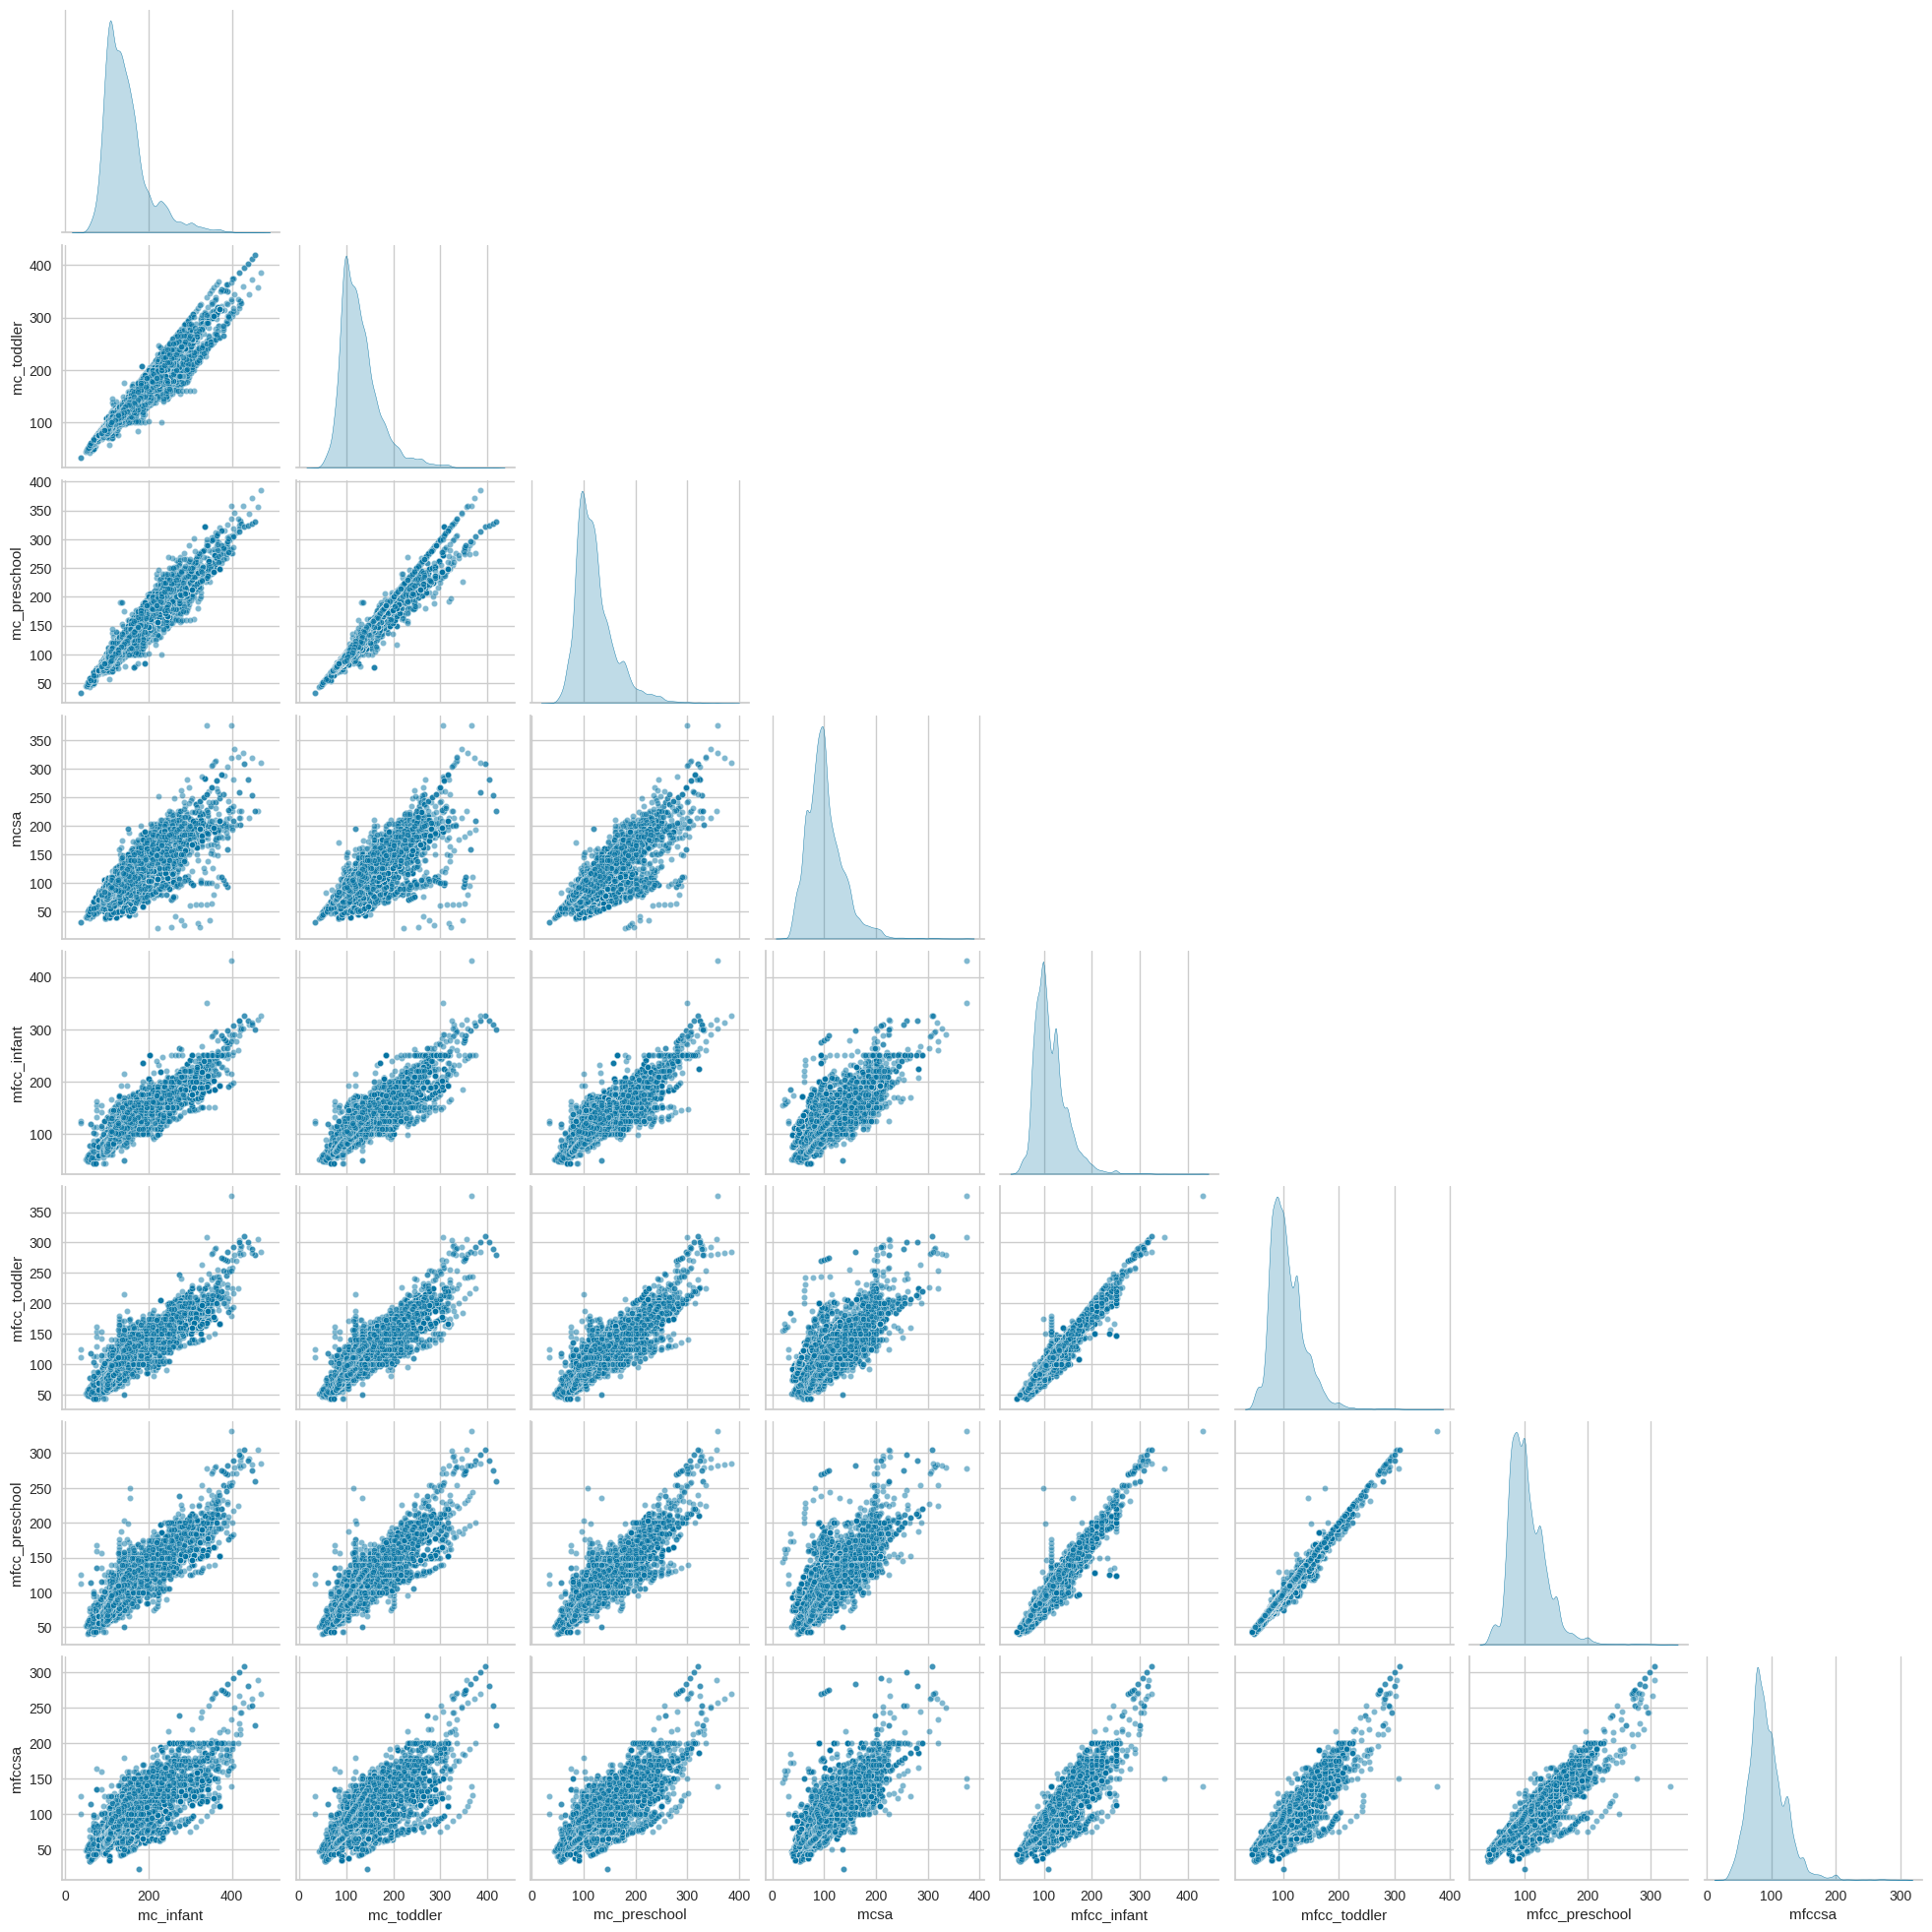

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

cost_df = childcare_clean[cost_cols]

pairplot = sns.pairplot(
    cost_df,
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 20}
)

plt.show()


#### Feature Correlation Structure
Correlation analysis was conducted to assess relationships among variables, showing that childcare cost measures are highly correlated with each other (≈0.89–0.99), while population and household count variables exhibit even stronger correlations (≈0.93–1.00), indicating pronounced multicollinearity in both feature groups.

<Axes: >

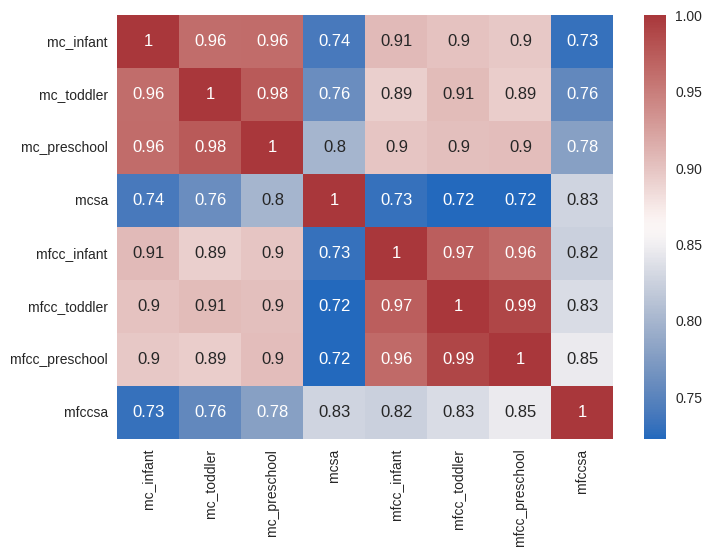

In [78]:
corr = cost_df.corr( numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

<Axes: >

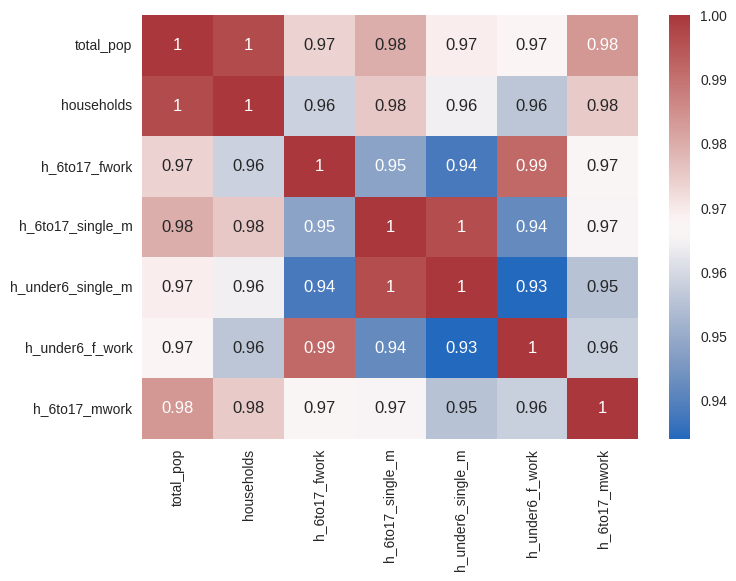

In [79]:
count_df = childcare_clean[count_cols]
corr = count_df.corr( numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

#### Pairwise Relationship Analysis of Population and Household Variables

Pairwise analysis was conducted to examine distributions and linear relationships among population and household count variables, revealing strong positive associations driven by county size and right-skewed distributions.

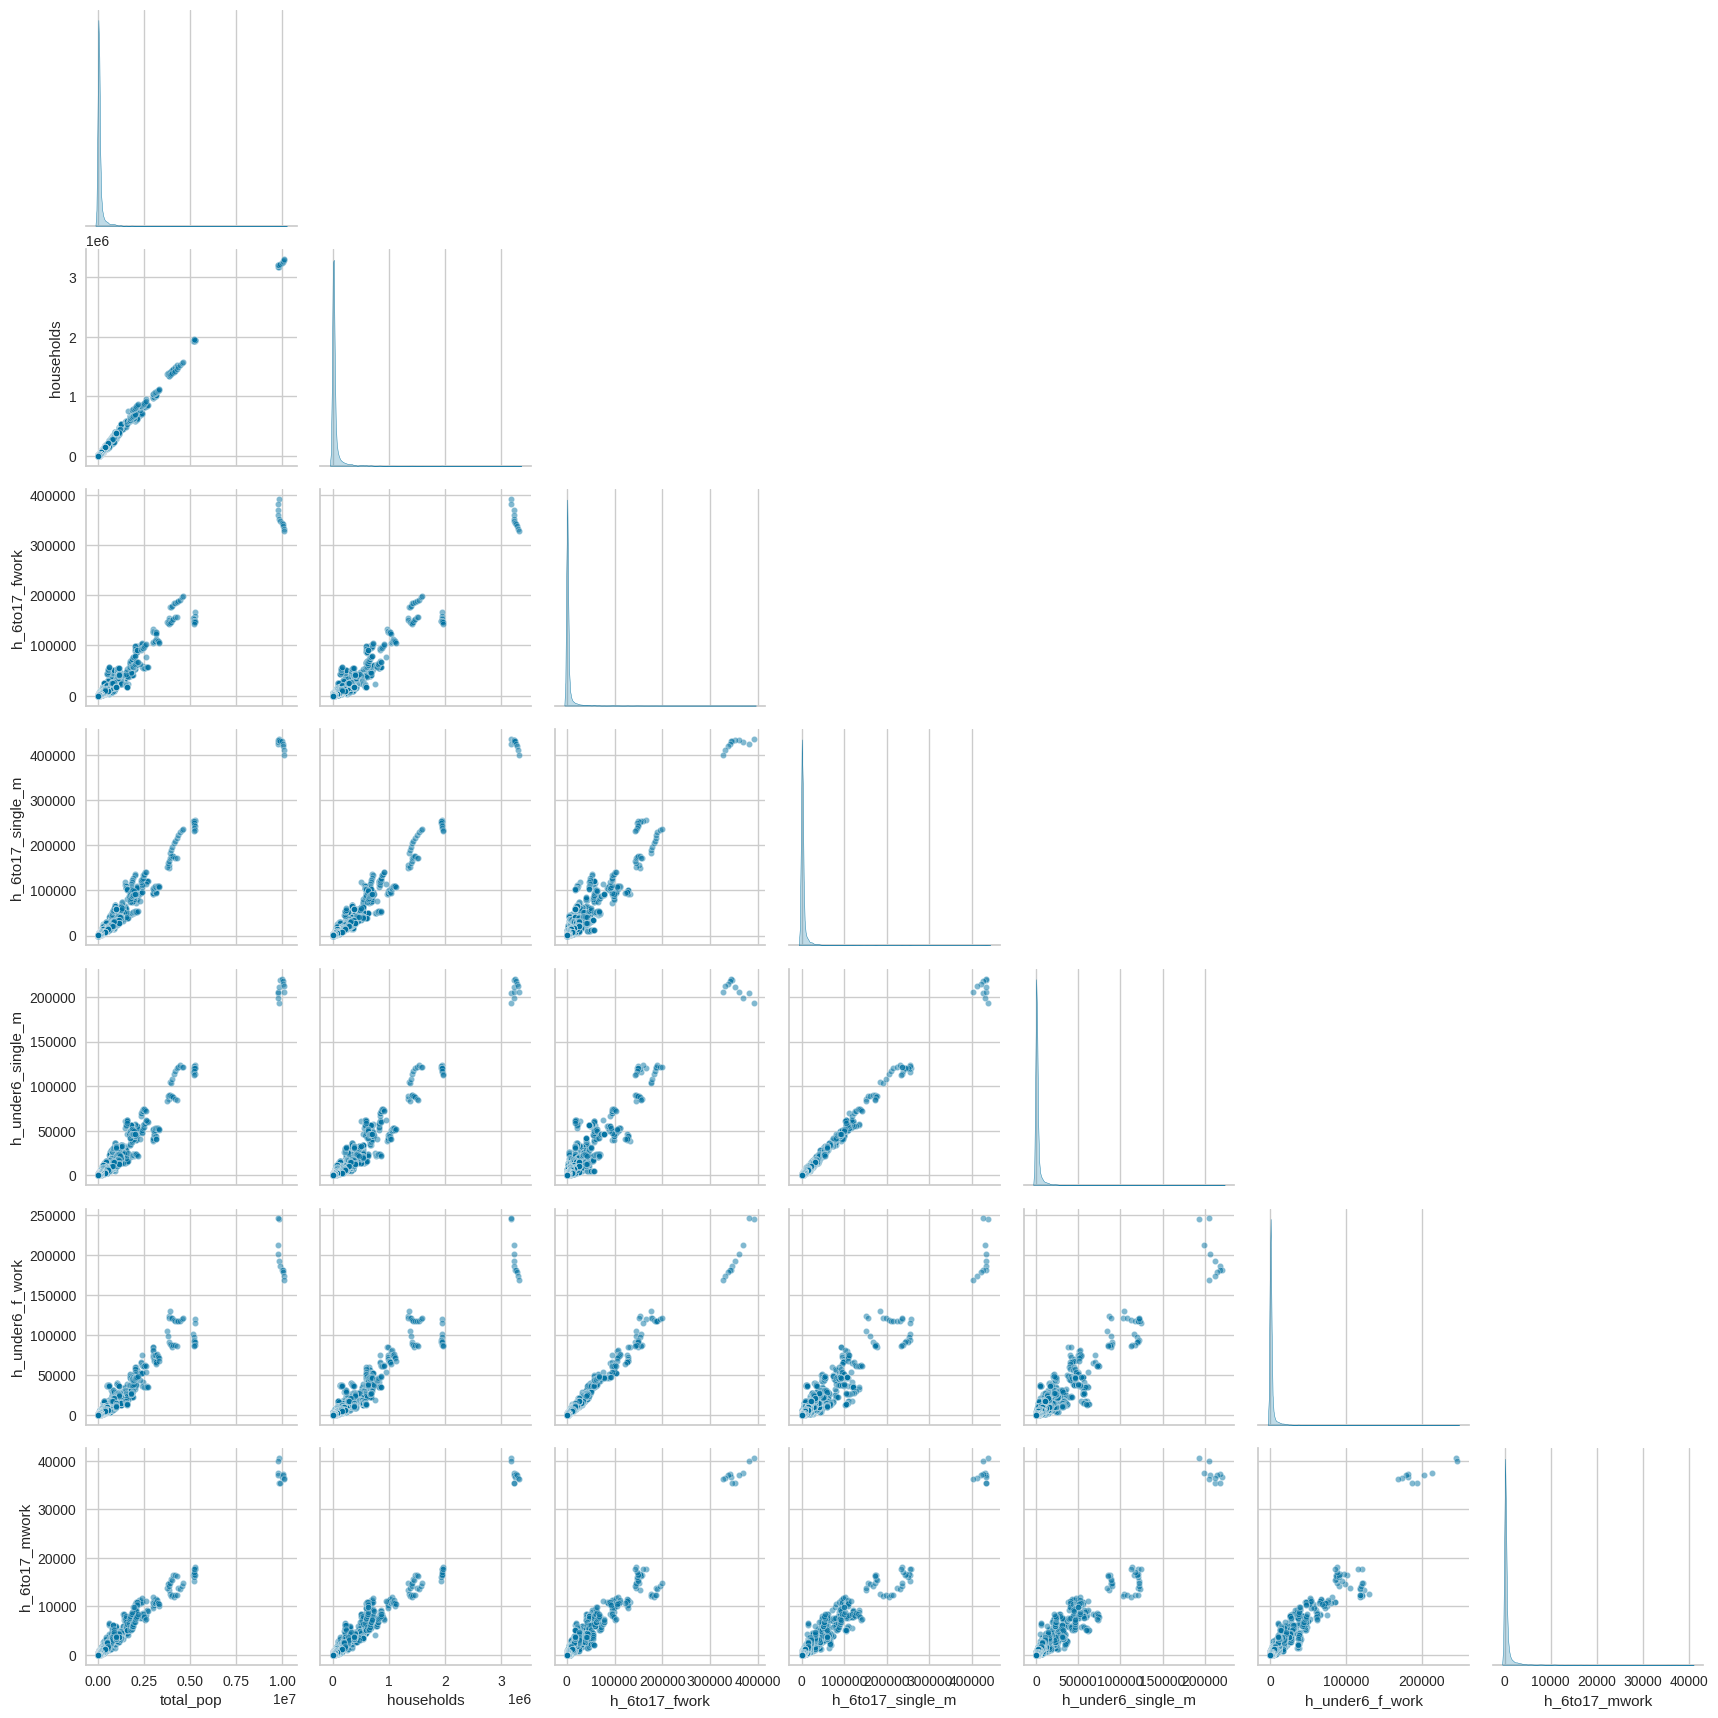

In [80]:
count_df = childcare_clean[count_cols]

pairplot = sns.pairplot(
    count_df,
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 20}
)

plt.show()


#### Normalization

Cost variables were standardized (mean = 0, std = 1) to ensure equal scale and prevent dominance in further analysis.

In [81]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_cost = childcare_clean[cost_cols]

x_cost_scaled = scaler.fit_transform(x_cost)

x_cost_scaled = pd.DataFrame(
    x_cost_scaled,
    columns=cost_cols,
    index=x_cost.index
)
x_cost_scaled.head()


,mc_infant,mc_toddler,mc_preschool,mcsa,mfcc_infant,mfcc_toddler,mfcc_preschool,mfccsa
0,-0.760837,-0.578337,-0.939269,-0.586440,-0.912068,-0.776245,-0.785747,-0.400439
1,-0.757849,-0.574656,-0.895706,-0.514128,-0.792037,-0.644831,-0.637943,-0.245609
2,-0.754675,-0.570746,-0.852143,-0.441817,-0.672006,-0.513418,-0.490140,-0.090779
3,-0.751500,-0.566836,-0.808581,-0.369216,-0.551671,-0.381671,-0.341991,0.064413
4,-0.748513,-0.563156,-0.765018,-0.296904,-0.431640,-0.250258,-0.194187,0.219243


In [82]:
x_count = childcare_clean[count_cols].copy()
x_count_log = np.log1p(x_count)

scaler = StandardScaler()
x_count_scaled = scaler.fit_transform(x_count_log)


x_count_scaled = pd.DataFrame(
    x_count_scaled,
    columns=count_cols,
    index=x_count.index
)

x_count_scaled.head()


,total_pop,households,h_6to17_fwork,h_6to17_single_m,h_under6_single_m,h_under6_f_work,h_6to17_mwork
0,0.332199,0.308881,0.363344,0.415773,0.402775,0.477861,0.053843
1,0.330019,0.305702,0.455317,0.511043,0.460562,0.474164,-0.061373
2,0.377083,0.357306,0.464160,0.529464,0.466351,0.501349,0.049104
3,0.387054,0.366971,0.613659,0.509482,0.422870,0.530732,0.468653
4,0.395111,0.364774,0.613032,0.593222,0.458442,0.457873,0.546303


In [83]:
X_afford = childcare_clean[afford_cols]

scaler = StandardScaler()
X_afford_scaled = scaler.fit_transform(X_afford)

X_afford_scaled = pd.DataFrame(
    X_afford_scaled,
    columns=afford_cols,
    index=X_afford.index
)

X_afford_scaled.head()


,afford_infant,afford_toddler,afford_preschool
0,-1.355103,-1.194766,-1.613973
1,-1.414577,-1.266420,-1.638306
2,-1.464382,-1.326425,-1.654244
3,-1.413201,-1.264762,-1.554387
4,-1.366776,-1.208831,-1.458064


## **Clustering on scaled data**

#### Optimal Cluster Selection (Elbow Method) - Cost Features

Elbow analysis shows a clear inflection around k ≈ 3–4, suggesting that 3 or 4 clusters are optimal for the cost features.

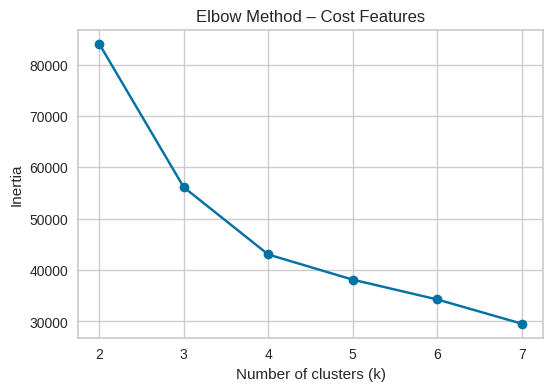

In [84]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_cost_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method – Cost Features")
plt.show()

#### Silhouette Analysis - Cost Features

Initial K=3 clustering was performed to segment counties based on standardized childcare cost features as a preliminary exploration, with the final number of clusters determined later using silhouette scores across all feature sets.

Silhouette analysis was performed to evaluate clustering quality; the average score (~0.4) indicates moderate separation and reasonably distinct cluster structure.

In [85]:
from sklearn.metrics import silhouette_score

for k in [3,4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_cost_scaled)
    score = silhouette_score(x_cost_scaled, labels)
    print(f"k={k}, silhouette score={score}")

k=3, silhouette score=0.4269441146476822
k=4, silhouette score=0.36781722007737805


In [86]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_cost_scaled)

childcare_clean.loc[:, 'cost_cluster'] = clusters

/tmp/ipython-input-3832639042.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  childcare_clean.loc[:, 'cost_cluster'] = clusters


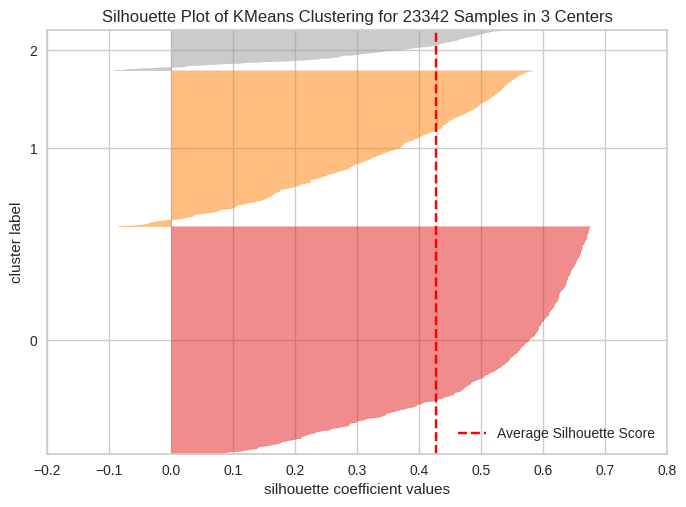

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23342 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [87]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans

k = 3

model = KMeans(n_clusters=k, random_state=42)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(x_cost_scaled)
visualizer.show()

#### Optimal Cluster Selection (Elbow Method) - Affordability Features

The elbow appears around k ≈ 3–4, suggesting 3–4 clusters are appropriate for the affordability features.


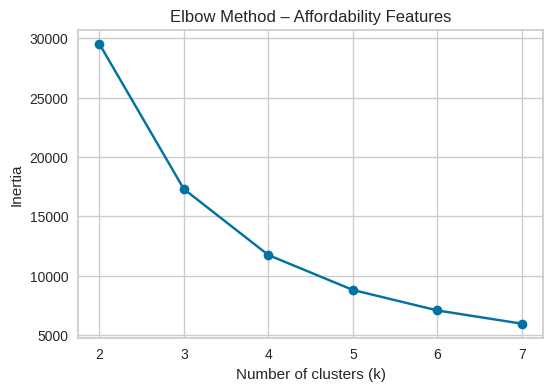

In [88]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_afford_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method – Affordability Features")
plt.show()

#### Silhouette Analysis - Affordability Features

In [89]:
from sklearn.metrics import silhouette_score

for k in [3,4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_afford_scaled)
    score = silhouette_score(X_afford_scaled, labels)
    print(f"k={k}, silhouette score={score}")

k=3, silhouette score=0.4830992637659631
k=4, silhouette score=0.45952566702918907


In [90]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_afford_scaled)

childcare_clean.loc[:, "afford_cluster"] = clusters

/tmp/ipython-input-661394224.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  childcare_clean.loc[:, "afford_cluster"] = clusters


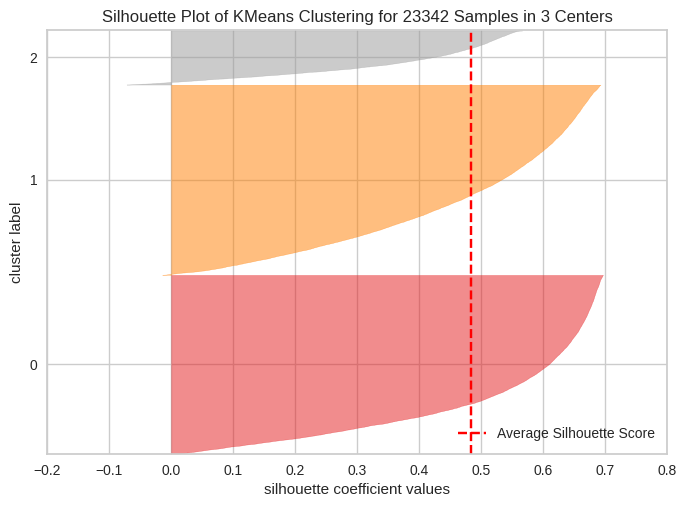

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23342 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [91]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans

k = 3

model = KMeans(n_clusters=k, random_state=42)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_afford_scaled)
visualizer.show()

## **PCA**

#### PCA for Cost feature set

PCA was applied to the standardized cost features to assess dimensional redundancy and variance structure. PC1 explains the vast majority of variance (~87–90%), while remaining components contribute minimally, indicating that the cost variables are highly collinear and largely driven by a single dominant underlying factor

In [92]:
!pip install psynlig -q

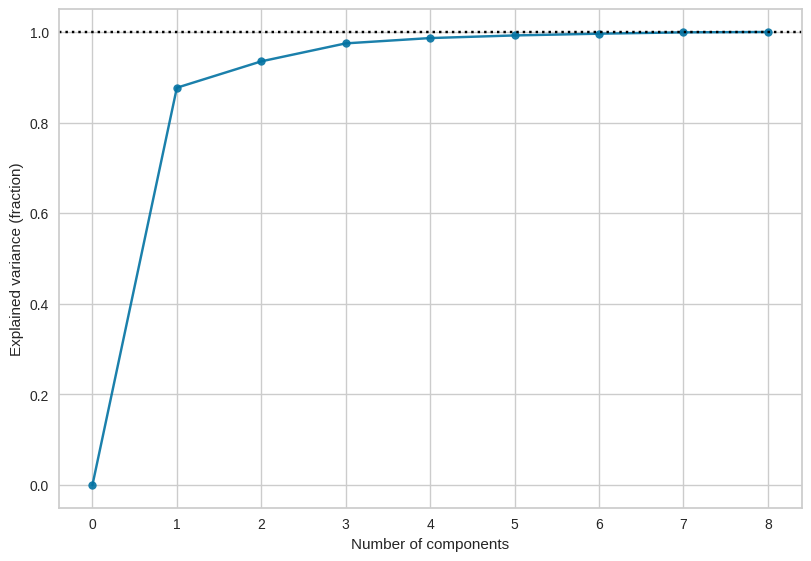

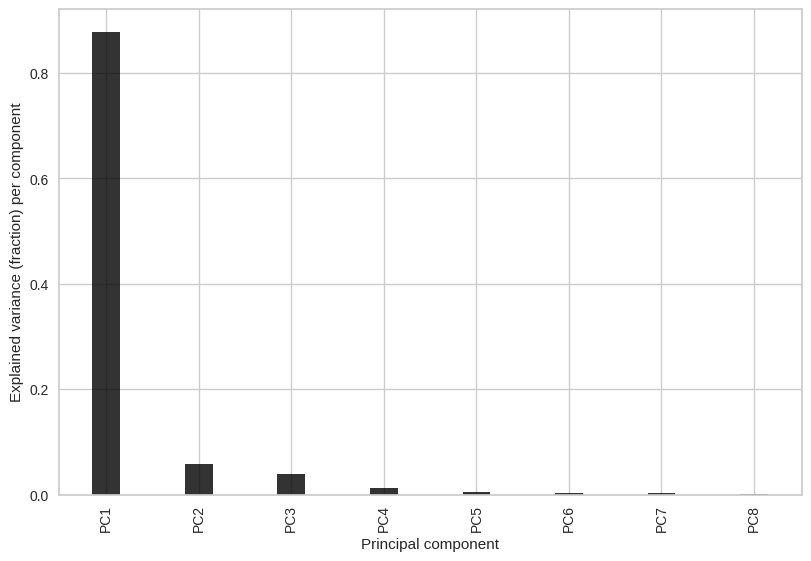

In [93]:
import numpy as np
from sklearn.decomposition import PCA
from psynlig import pca_explained_variance, pca_explained_variance_bar
import matplotlib.pyplot as plt

# Fit PCA (full)
pca_cost = PCA()
pca_cost.fit(x_cost_scaled)

# Prof-style plots (dots included)
_, ax = pca_explained_variance(pca_cost, marker='o', markersize=6, alpha=0.9)
plt.show()

pca_explained_variance_bar(pca_cost, width=0.3, alpha=0.8, color="black")
plt.show()



PCA reduced the cost features to 2 components (23,342 × 2), capturing most variance driven by overall childcare cost level.

In [94]:
# Apply PCA with chosen components
pca_cost_model = PCA(n_components=2)
X_pca_cost = pca_cost_model.fit_transform(x_cost_scaled)

# check shape
X_pca_cost.shape

(23342, 2)

#### PCA for Affordability feature set

PCA on the affordability features shows that PC1 explains ~96–97% of total variance, while PC2 and PC3 contribute minimally, indicating that affordability variables are highly collinear and largely driven by a single dominant affordability factor across counties.

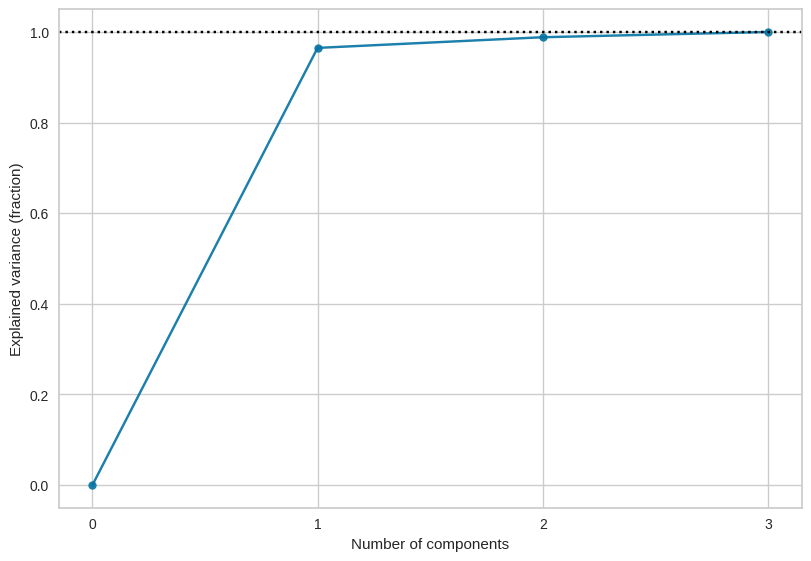

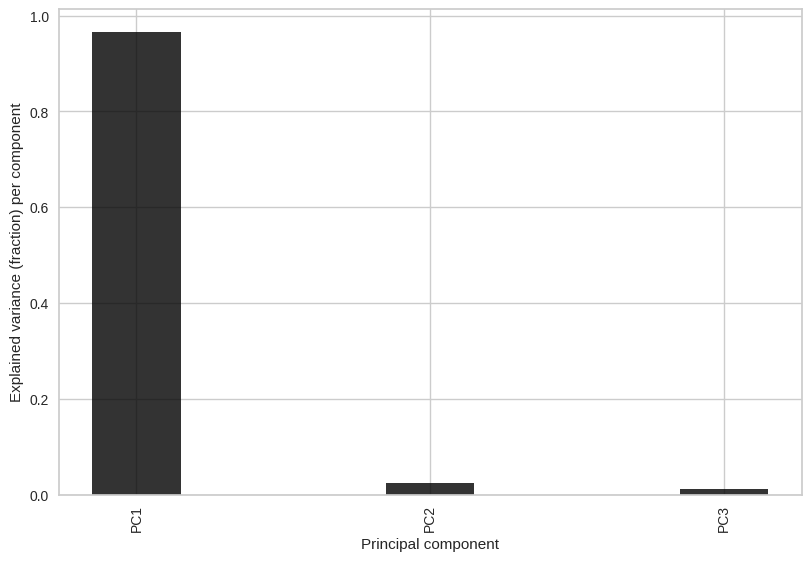

In [95]:
# Fit PCA (full)
pca_aff = PCA()
pca_aff.fit(X_afford_scaled)

# Prof-style plots (dots included)
_, ax = pca_explained_variance(pca_aff, marker='o', markersize=6, alpha=0.9)
plt.show()

pca_explained_variance_bar(pca_aff, width=0.3, alpha=0.8, color="black")
plt.show()

PCA reduced the affordability feature set to one principal component (23,342 × 1), meaning a single latent affordability factor captures nearly all variance in the original variables.

In [96]:
# Apply PCA with chosen components
pca_aff_model = PCA(n_components=1)
X_pca_aff = pca_aff_model.fit_transform(X_afford_scaled)

# check shape
X_pca_aff.shape

(23342, 1)

## **Clustering on PCA data**

### Determine best K

Define Feature Sets

In [97]:
# Dictionary to store all datasets for clustering
feature_sets = {
    "Cost_PCA": X_pca_cost,
    "Afford_PCA": X_pca_aff
}


Run KMeans and Evaluate

K-Means (k=2–7) was tested on Cost_PCA and Afford_PCA; the optimal K is the one with the highest silhouette score, and cluster_sizes show cluster balance.

In [98]:
results = []
k_range = range(2, 8)

for feature_name, data in feature_sets.items():
    data = np.array(data)

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(data)

        sil = silhouette_score(data, labels)
        cluster_sizes = pd.Series(labels).value_counts().sort_index().tolist()

        results.append({
            "method": "KMeans",
            "feature_set": feature_name,
            "K": k,
            "silhouette": sil,
            "cluster_sizes": cluster_sizes
        })

results_kmeans = pd.DataFrame(results)
results_kmeans

,method,feature_set,K,silhouette,cluster_sizes
0,KMeans,Cost_PCA,2,0.565784,"[6157, 17185]"
1,KMeans,Cost_PCA,3,0.478756,"[8572, 2251, 12519]"
2,KMeans,Cost_PCA,4,0.435135,"[8689, 9143, 4366, 1144]"
3,KMeans,Cost_PCA,5,0.380342,"[5124, 3422, 987, 5942, 7867]"
4,KMeans,Cost_PCA,6,0.376076,"[239, 4545, 3491, 5775, 1449, 7843]"
5,KMeans,Cost_PCA,7,0.409132,"[3362, 6692, 1426, 4925, 4509, 279, 2149]"
6,KMeans,Afford_PCA,2,0.561251,"[14962, 8380]"
7,KMeans,Afford_PCA,3,0.535480,"[10663, 9573, 3106]"
8,KMeans,Afford_PCA,4,0.531244,"[6643, 5921, 9495, 1283]"
9,KMeans,Afford_PCA,5,0.529019,"[2996, 5168, 6578, 593, 8007]"


Run Hierarchical Clustering

Hierarchical clustering (Ward linkage) was evaluated for k=2–7 on both PCA feature sets.

* For Cost_PCA, the highest silhouette score occurs at k=2 (≈0.61), indicating two well-separated clusters.
* For Afford_PCA, the best separation appears around k=4 (≈0.52), though k=2–4 show comparable structure.

Cluster sizes indicate some imbalance, especially for higher k values.

In [62]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

results = []
k_range = range(2, 8)

for feature_name, data in feature_sets.items():
    data = np.array(data)

    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = model.fit_predict(data)

        sil = silhouette_score(data, labels)
        cluster_sizes = pd.Series(labels).value_counts().sort_index().tolist()

        results.append({
            "method": "Hierarchical",
            "feature_set": feature_name,
            "K": k,
            "silhouette": sil,
            "cluster_sizes": cluster_sizes
        })

results_hier = pd.DataFrame(results)
results_hier

,method,feature_set,K,silhouette,cluster_sizes
0,Hierarchical,Cost_PCA,2,0.606069,"[21293, 2049]"
1,Hierarchical,Cost_PCA,3,0.435550,"[10957, 2049, 10336]"
2,Hierarchical,Cost_PCA,4,0.357370,"[2049, 5432, 10336, 5525]"
3,Hierarchical,Cost_PCA,5,0.348115,"[10336, 5432, 682, 5525, 1367]"
4,Hierarchical,Cost_PCA,6,0.300316,"[5432, 5593, 682, 5525, 1367, 4743]"
5,Hierarchical,Cost_PCA,7,0.331470,"[5593, 1975, 682, 5525, 1367, 4743, 3457]"
6,Hierarchical,Afford_PCA,2,0.566156,"[18714, 4628]"
7,Hierarchical,Afford_PCA,3,0.509339,"[4628, 10018, 8696]"
8,Hierarchical,Afford_PCA,4,0.522151,"[10018, 3977, 8696, 651]"
9,Hierarchical,Afford_PCA,5,0.498794,"[8696, 3977, 4192, 651, 5826]"


Stability Check (KMeans)

The stability check shows that silhouette scores remain consistent across repeated K-Means runs.

* For Cost_PCA, k=2 consistently produces the strongest and most stable clustering.
* For Afford_PCA, scores are relatively stable across k=2–7, with k=2 slightly highest, indicating robust but gradually weakening structure as clusters increase.

In [99]:
from sklearn.metrics import silhouette_score
from IPython.display import display

stability_results = []

for feature_name, data in feature_sets.items():
    data = np.array(data)
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(data)
        sil = silhouette_score(data, labels)
        stability_results.append({
            "method": "KMeans_stability",
            "feature_set": feature_name,
            "K": k,
            "silhouette": sil
        })

stability_df = pd.DataFrame(stability_results)
display(stability_df)
print(f"Total stability runs: {len(stability_df)}")

,method,feature_set,K,silhouette
0,KMeans_stability,Cost_PCA,2,0.565784
1,KMeans_stability,Cost_PCA,3,0.478756
2,KMeans_stability,Cost_PCA,4,0.435135
3,KMeans_stability,Cost_PCA,5,0.380342
4,KMeans_stability,Cost_PCA,6,0.376076
5,KMeans_stability,Cost_PCA,7,0.409132
6,KMeans_stability,Afford_PCA,2,0.561251
7,KMeans_stability,Afford_PCA,3,0.535480
8,KMeans_stability,Afford_PCA,4,0.531244
9,KMeans_stability,Afford_PCA,5,0.529019


Total stability runs: 12


Final Deliverable Table

The final table shows the best-performing model for each method and feature set, selected based on the highest silhouette score.

Results indicate that k=2 is optimal across all configurations, with Hierarchical (Cost_PCA) achieving the strongest overall separation (≈0.61), followed by Hierarchical (Afford_PCA) and KMeans variants, confirming a consistent two-cluster structure in the data.

In [100]:
results_df = pd.concat([results_kmeans, results_hier], ignore_index=True)

In [101]:
# For each method + feature set choose highest silhouette
best_models = (
    results_df
    .sort_values("silhouette", ascending=False)
    .groupby(["method", "feature_set"], as_index=False)
    .first()
)

# Keep only required columns
final_table = best_models[["method", "feature_set", "K", "silhouette"]]

# Rename K column
final_table = final_table.rename(columns={"K": "best_K"})

# Sort nicely
final_table = final_table.sort_values(["method", "feature_set"]).reset_index(drop=True)

final_table

,method,feature_set,best_K,silhouette
0,Hierarchical,Afford_PCA,2,0.566156
1,Hierarchical,Cost_PCA,2,0.606069
2,KMeans,Afford_PCA,2,0.561251
3,KMeans,Cost_PCA,2,0.565784


## **Model Selection and Validation**

### KMeans Stability Test Using Bootstrap

Both feature sets show extremely high stability (ARI ≈ 0.99) with very low variability across bootstrap runs.

This indicates that the two-cluster structure is highly reproducible and robust to subsampling. The segmentation reflects a strong underlying structure rather than random initialization effects.

Cost_PCA shows slightly higher stability than Afford_PCA, but both are statistically very strong and reliable.

In [117]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np
import pandas as pd

def stability_ari_kmeans(X, k, n_runs=20, sample_frac=0.8):
    label_runs = []

    for seed in range(n_runs):
        n = int(sample_frac * len(X))
        idx = np.random.default_rng(seed).choice(len(X), n, replace=False)
        labels = KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(X[idx])
        label_runs.append((idx, labels))

    aris = []
    for i in range(len(label_runs) - 1):
        idx1, lab1 = label_runs[i]
        idx2, lab2 = label_runs[i + 1]

        common = np.intersect1d(idx1, idx2)

        m1 = pd.Series(lab1, index=idx1).loc[common]
        m2 = pd.Series(lab2, index=idx2).loc[common]

        aris.append(adjusted_rand_score(m1, m2))

    return np.mean(aris), np.std(aris)

In [118]:
mean_ari_cost, std_ari_cost = stability_ari_kmeans(X_pca_cost, k=2)

print("Cost_PCA Stability (K=2)")
print(f"Mean ARI: {mean_ari_cost:.4f}")
print(f"Std ARI: {std_ari_cost:.4f}")

Cost_PCA Stability (K=2)
Mean ARI: 0.9935
Std ARI: 0.0088


In [121]:
mean_ari_aff, std_ari_aff = stability_ari_kmeans(X_pca_aff, k=2)
print("Afford_PCA Stability (K=2)")
print(f"Mean ARI: {mean_ari_aff:.4f}")
print(f"Std ARI: {std_ari_aff:.4f}")

Afford_PCA Stability (K=2)
Mean ARI: 0.9851
Std ARI: 0.0115


### Gap Statistic

The method mathematically favors higher K (6–7).

However, because the increase is smooth rather than peaked, this likely reflects increasing model complexity rather than a strong natural segmentation.

This indicates the data may have a weak or gradual structure, not sharply separated groups.

In [188]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd
def gap_statistic(X, k_range=range(2,8), b=10, random_state=42):
    rng = np.random.default_rng(random_state)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    gaps = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10).fit(X)
        log_wk = np.log(km.inertia_)

        ref_logs = []
        for _ in range(b):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            km_ref = KMeans(n_clusters=k, random_state=random_state, n_init=10).fit(X_ref)
            ref_logs.append(np.log(km_ref.inertia_))
        gap = np.mean(ref_logs) - log_wk
        gaps.append(gap)
    return pd.DataFrame({"k": list(k_range), "gap": gaps})

gap_df = gap_statistic(X_pca_cost)
gap_df.sort_values("gap", ascending=False).head()

,k,gap
5,7,1.835347
4,6,1.818154
3,5,1.792538
2,4,1.734178
0,2,1.678800


### GMM Model Selection on Cost_PCA and Afford_PCA

**Afford_PCA:**

* Highest Silhouette: K = 2 (0.566)

* Silhouette decreases as K increases

* BIC slightly lowest at K = 5

The strongest cluster separation occurs at K = 2, indicating a clear two-segment affordability structure. Higher K values improve model fit slightly (BIC) but reduce separation quality, suggesting over-segmentation.

**Cost_PCA:**

* Highest Silhouette: K = 4 (0.268)

* Overall silhouette values are low

* BIC gradually decreases with higher K

Clustering structure is weak. Even at optimal K, separation remains moderate, indicating cost variables form overlapping rather than distinct segments.

In [122]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd

def run_gmm_evaluation(X, feature_name):
    rows = []

    for k in range(2, 8):
        gmm = GaussianMixture(n_components=k, random_state=42)
        labels = gmm.fit_predict(X)

        rows.append({
            "Feature_Set": feature_name,
            "K": k,
            "BIC": gmm.bic(X),
            "AIC": gmm.aic(X),
            "LogLikelihood": gmm.score(X),
            "Silhouette": silhouette_score(X, labels)
        })

    return pd.DataFrame(rows)

In [125]:
gmm_cost_df = run_gmm_evaluation(X_pca_cost, "Cost_PCA")
gmm_aff_df = run_gmm_evaluation(X_pca_aff, "Afford_PCA")
gmm_all = pd.concat([gmm_cost_df, gmm_aff_df], ignore_index=True)
gmm_all.sort_values(["Feature_Set", "K"])

,Feature_Set,K,BIC,AIC,LogLikelihood,Silhouette
6,Afford_PCA,2,88796.652757,88756.362709,-1.901002,0.565857
7,Afford_PCA,3,88477.845963,88413.381887,-1.893526,0.536043
8,Afford_PCA,4,88407.974350,88319.336245,-1.891383,0.530579
9,Afford_PCA,5,88381.151792,88268.339658,-1.890162,0.529082
10,Afford_PCA,6,88436.212781,88299.226618,-1.890695,0.521535
11,Afford_PCA,7,88447.175711,88286.015519,-1.890284,0.519502
0,Cost_PCA,2,142350.455974,142261.817868,-3.046864,0.253770
1,Cost_PCA,3,139758.574144,139621.587981,-2.990052,0.224709
2,Cost_PCA,4,138253.441473,138068.107253,-2.956518,0.267818
3,Cost_PCA,5,137634.353995,137400.671717,-2.941965,0.194593


#### Distance Metric Sensitivity Analysis (Euclidean vs Cosine)

Cosine-based clustering clearly outperforms Euclidean across all k values. At k=2, cosine achieves a silhouette of 0.744 compared to 0.530 under Euclidean, and this gap persists as k increases. This indicates that counties cluster more strongly based on relative feature patterns (direction) rather than absolute magnitude differences. Importantly, k=2 remains optimal under both metrics, reinforcing a stable two-cluster structure while suggesting cosine similarity captures the separation more effectively.

In [182]:
from sklearn.preprocessing import normalize

# X_std = standardized features
X_norm = normalize(x_cost_scaled)

In [187]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for k in range(2, 6):

    # Euclidean KMeans
    km_e = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_e = km_e.fit_predict(x_cost_scaled)
    results.append({
        "approach": "Euclidean",
        "k": k,
        "silhouette": silhouette_score(x_cost_scaled, labels_e, metric="euclidean")
    })

    # Cosine-like KMeans
    km_c = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_c = km_c.fit_predict(X_norm)
    results.append({
        "approach": "Cosine",
        "k": k,
        "silhouette": silhouette_score(X_norm, labels_c, metric="cosine")
    })

metric_comparison = pd.DataFrame(results)
metric_comparison.sort_values(["approach", "k"])

,approach,k,silhouette
1,Cosine,2,0.744299
3,Cosine,3,0.682560
5,Cosine,4,0.662378
7,Cosine,5,0.658640
0,Euclidean,2,0.529575
2,Euclidean,3,0.426944
4,Euclidean,4,0.367239
6,Euclidean,5,0.297898


In [186]:
metric_comparison.pivot(index="k", columns="approach", values="silhouette")

approach,Cosine,Euclidean
k,,
2,0.744299,0.529575
3,0.682560,0.426944
4,0.662378,0.367239
5,0.658640,0.297898


## **Geographic Distribution of Childcare Cost and Affordability Segments**

The cost-based clusters show high-cost counties concentrated along the West Coast, Northeast, and major metropolitan areas, while lower-cost counties dominate the Midwest and interior South.

In contrast, the affordability clusters are more widespread across the South and parts of the Midwest, indicating that affordability pressures are driven not only by cost levels but also by regional income differences. Together, the maps suggest that cost concentration is largely urban and coastal, whereas affordability disparities reflect broader structural economic variation.

#### Preprocessing for Geographic Visualization

In [172]:
### Spatial Data Preparation and Merge

# FIPS formatting
childcare_clean = childcare_clean.copy()

childcare_clean["county_fips_code"] = (
    childcare_clean["county_fips_code"]
    .astype(str)
    .str.zfill(5)
)

us_map["id"] = us_map["id"].astype(str)

# Merge
us_clustered = us_map.merge(
    childcare_clean,
    left_on="id",
    right_on="county_fips_code",
    how="inner"
)

In [173]:
kmeans_cost = KMeans(n_clusters=2, random_state=42, n_init=10)
childcare_clean["cost_cluster"] = kmeans_cost.fit_predict(X_pca_cost)

kmeans_aff = KMeans(n_clusters=2, random_state=42, n_init=10)
childcare_clean["afford_cluster"] = kmeans_aff.fit_predict(X_pca_aff)

In [127]:
!pip install geopandas

In [163]:
import geopandas as gpd

# Use US Census TIGER county shapefile
us_map = gpd.read_file("https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json")

In [179]:
missing = set(childcare_clean["county_fips_code"]) - set(us_map["id"])
print(missing)
#historical mismatch - In 2015, Shannon County (FIPS 46113) was renamed to Oglala Lakota County and its FIPS changed to 46102. Many shapefiles still use the old FIPS (46113)

{'46102'}


#### Geographic Distribution of Cost-Based Clusters

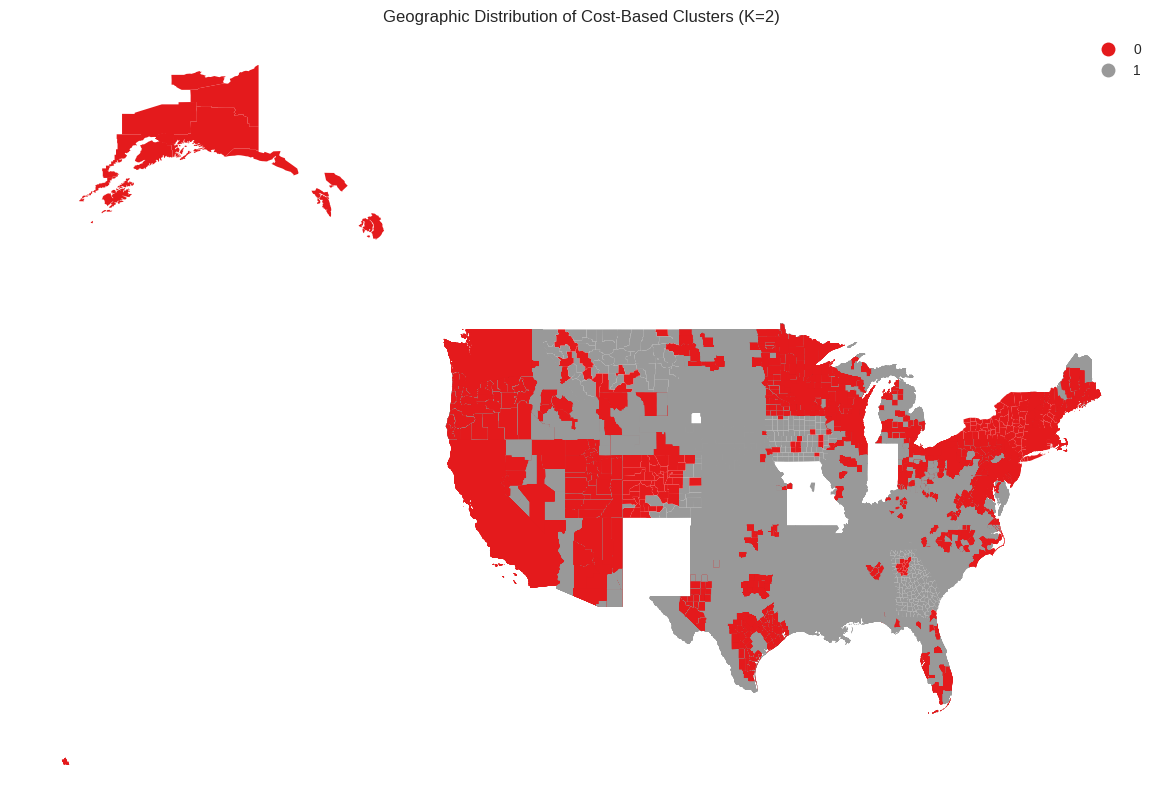

In [165]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(15,10))

us_clustered_clean.plot(
    column="cost_cluster",
    categorical=True,
    legend=True,
    cmap="Set1",
    linewidth=0.1,
    ax=ax
)

ax.set_title("Geographic Distribution of Cost-Based Clusters (K=2)")
ax.axis("off")
plt.show()

#### Geographic Distribution of Affordability Clusters

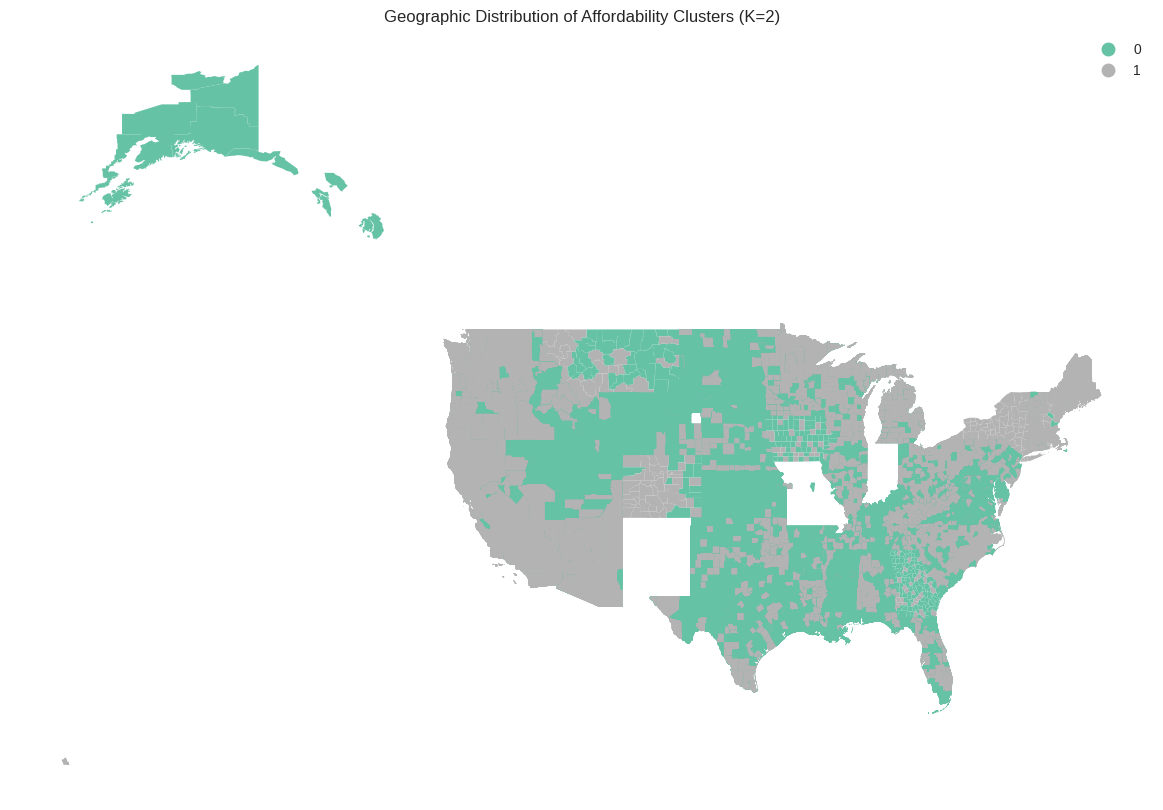

In [168]:
fig, ax = plt.subplots(1, 1, figsize=(15,10))

us_clustered.plot(
    column="afford_cluster",
    categorical=True,
    legend=True,
    cmap="Set2",
    linewidth=0.1,
    ax=ax
)

ax.set_title("Geographic Distribution of Affordability Clusters (K=2)")
ax.axis("off")
plt.show()